In [32]:

from pathlib import Path
import pandas as pd
import numpy as np

import os
import glob
import re

import matplotlib as mpl 
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D

import metisse_wrapper as mw

In [2]:
METISSE_DIR = "../../.."     # replace it with your path

run_dir = os.path.join(os.getcwd(),'run')


In [3]:
# 1) Compile METISSE (this will call './mk' in METISSE_DIR and copy the executable to run_dir)
mw.compile_metisse(METISSE_DIR, run_dir)

In [49]:

# Paths to the precomputed stellar track libraries 
# (replace these with your actual directories or keep them if already correct)
metisse_params = {
    "metallicity_dir": "/Users/poojan/stellar_tracks/MESA/METISSE_INPUT_FILES/Hydrogen/",
    "metallicity_dir_he": "/Users/poojan/stellar_tracks/MESA/METISSE_INPUT_FILES/Helium/",
}

main_params = {
    "initial_Z": 0.02,
    "max_age": 2.0e4,             
    "number_of_tracks": 100,
    "min_mass": 10.0,
    "max_mass": 100.0,
    "sampling_scheme": "Uniform",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}

# 2) Run METISSE (this will launch the './metisse' executable inside run_dir)
mw.run_metisse(str(run_dir),main_params, metisse_params)



## Hertzsprung–Russell Diagram
The HR diagram shows a star’s luminosity versus effective temperature.  
Here, we visualize METISSE’s output using a Hertzsprung–Russell diagram (HRD).

The following script plots Hertzsprung–Russell diagram (HRD) from METISSE output files,
color-coded by stellar mass.



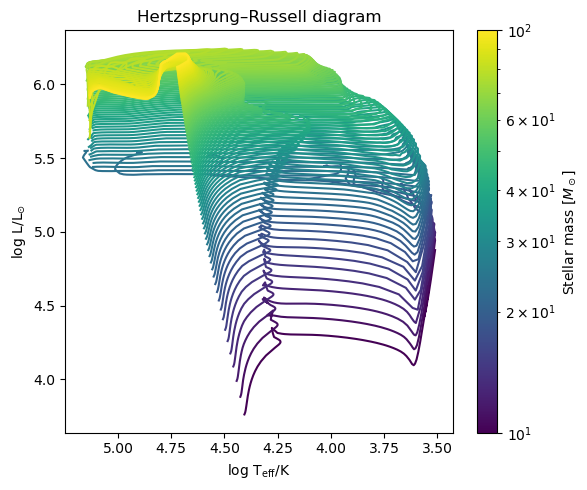

In [ ]:

phase_lim = 5                # Only include evolution up to this phase
base_name = os.path.join(run_dir, 'output')

fig, ax = plt.subplots(figsize=(6,5))

# Logarithmic color normalization for stellar mass
norm = mpl.colors.LogNorm(vmin=10, vmax=100.0)
cmap = mpl.cm.ScalarMappable(norm=norm, cmap='viridis')  # choose any cmap you like
cmap.set_array([])

# --- Read all .dat track files ---
file_name = glob.glob(base_name + "/*.dat")
file_name.sort()

# --- Plot each track ---
for eachfile in file_name:
    # Extract 5-digit mass value from filename (e.g., '00005' -> 5.0 Msun)
    mass = re.findall(r"[0-9]{5}", eachfile)[0]
    m = float(mass) / 100.0

    # Read stellar evolution data
    evolve_data = pd.read_table(eachfile, sep=r"\s+")
    evolve_data = evolve_data[evolve_data.phase <= phase_lim]

    Teff = evolve_data['log_Teff']
    L = evolve_data['log_L']

    # Plot track with color determined by mass
    ax.plot(Teff, L, color=cmap.to_rgba(m))

# --- Add colorbar for stellar mass ---
cbar = plt.colorbar(cmap, ax=ax)
cbar.set_label(r'Stellar mass [$M_\odot$]')
cbar.ax.tick_params(labelsize=10)

ax.set_xlabel(r'log T$_{\mathrm{eff}}$/K')
ax.set_ylabel(r'log L/L$_{\odot}$')
ax.invert_xaxis()  
ax.set_title("Hertzsprung–Russell diagram")

plt.tight_layout()
plt.show()


## Maximum Stellar Radius

In the HR diagram above, we followed the full evolutionary track of a single star, showing how its temperature and luminosity change over time.  
A key outcome of that evolution is the star’s changing radius — as it expands off the main sequence, it may fill its Roche lobe in a binary system.  
By plotting the *maximum stellar radius* against *initial mass* for many such tracks, we can identify which stars are likely to undergo binary interaction.


Th following script plots the *maximum stellar radius* reached during the evolution
of stars of different initial masses,
color-coded by evolutionary phase.


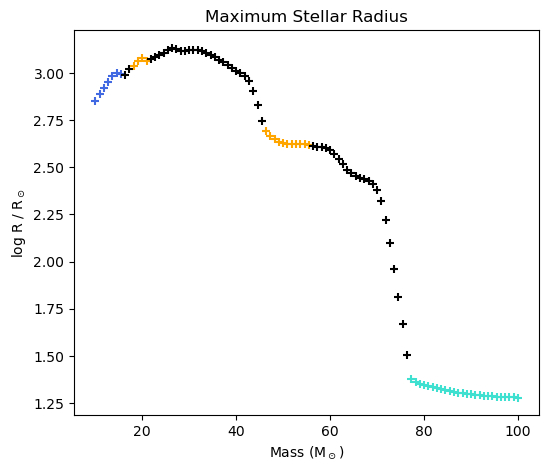

In [46]:

def plot_max_rad(ax, name, i=0):
    """
    Plot the maximum stellar radius as a function of initial mass.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        The plot axis on which to draw the scatter points.
    name : str
        Directory under run_dir containing evolution track files (*.dat).
    i : int, optional
        Marker style index (default: 0). Allows differentiating model sets.
    """
    # Colors for different evolutionary phases (e.g., MS, RGB, HeB, etc.)
    color = ['springgreen', 'turquoise', 'black', 'skyblue',
             'orange', 'royalblue', 'salmon']

    base_dir = os.path.join(run_dir, name)
    file_names = glob.glob(base_dir + "/*.dat")
    file_names.sort()  # consistent order by increasing mass

    for eachfile in file_names:
        # Extract the initial mass from the filename (e.g. "00500" → 5.00 M_sun)
        mass = re.findall(r"[0-9]{5}", eachfile)[0]
        m = float(mass) / 100.0

        # Read the stellar evolution track
        evolve_data = pd.read_table(eachfile, sep=r"\s+")

        # Find maximum stellar radius (in log R/Rsun)
        R = max(evolve_data['log_radius'])

        # Identify the evolutionary phase where max radius occurs
        p = evolve_data['phase'].iloc[np.argmax(evolve_data['log_radius'])]

        # Plot as a colored scatter point (color encodes phase)
        ax.scatter(m, R, marker=markerlist[i], c=color[p])

    return


# ---------------------------------------------------------------------
# Plot setup
# ---------------------------------------------------------------------
markerlist = ['+', '.', '*']

# Limit the plot to evolution up to a certain phase (optional)
phase_lim = 5

fig, ax = plt.subplots(figsize=(6, 5))

# Replace with your working directory path before running
# run_dir = "/path/to/METISSE_runs"

# Call the function to plot all stars in the given directory
plot_max_rad(ax, 'output')

ax.set_xlabel(r'Mass (M$_\odot$)')
ax.set_ylabel(r'log R / R$_\odot$')
ax.set_title('Maximum Stellar Radius')

plt.show()



Let us now compare how stellar tracks from MIST and BoOST datasets compare to the MESA tracks.  
We run METISSE sequentially with different stellar track libraries:

1. **MIST** – to use MIST [(Choi et al., 2016)]() models at solar metallicity, the tracks can be downloaded from the [website](), while the corresponding metallicity and format files needed by METISSE are available from [this page]().  
2. **BoOST** – stellar model grids for Galactic metallicity, computed with the Bonn Code, are available [here](http://galaxy.asu.cas.cz/files/BoOST/BoOST-stellarmodels-MW.zip). The helper files required for METISSE are available [here]().


In [25]:
# --- Rename existing MESA output directory ---

current_name = Path(os.path.join(run_dir, 'output'))
new_name = os.path.join(run_dir, 'output_MESA')

current_name.rename(new_name)

# --------------------------------------------------------------
# Run METISSE with MIST stellar tracks
# --------------------------------------------------------------

metisse_params = {
    "metallicity_dir": "/Users/poojan/stellar_tracks/MIST/",
}

main_params = {
    "initial_Z": 0.014,
    "max_age": 2.0e4,             
    "number_of_tracks": 100,
    "min_mass": 10.0,
    "max_mass": 100.0,
    "sampling_scheme": "Uniform",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}


# Run METISSE (custom Python wrapper function)
mw.run_metisse(str(run_dir),main_params, metisse_params)



OSError: [Errno 66] Directory not empty: '/Users/poojan/softwares/METISSE/docs/source/notebook/run/output' -> '/Users/poojan/softwares/METISSE/docs/source/notebook/run/output_MESA'

In [34]:
# Rename MIST output directory
new_name = os.path.join(run_dir, 'output_MIST')
current_name.rename(new_name)


# ---------------------------------------------------------------------
# Run METISSE with BOOST tracks
# ---------------------------------------------------------------------

metisse_params = {
    "metallicity_dir": "/Users/poojan/stellar_tracks/Boost/tracks",
}

main_params = {
    "initial_Z": 0.008,         # Galactic metallicity for Boost tracks
    "max_age": 2.0e4,             
    "number_of_tracks": 100,
    "min_mass": 10.0,
    "max_mass": 100.0,
    "sampling_scheme": "Uniform",
    "BHNS_mass_scheme": "Belczynski2008",
    "write_output_to_file": True,
}


mw.run_metisse(str(run_dir),main_params, metisse_params)

# Rename Boost output directory
new_name = os.path.join(run_dir, 'output_BOOST')
current_name.rename(new_name)

OSError: [Errno 66] Directory not empty: '/Users/poojan/softwares/METISSE/docs/source/notebook/run/output' -> '/Users/poojan/softwares/METISSE/docs/source/notebook/run/output_MIST'

With the METISSE runs complete for MESA, MIST, and BoOST libraries,  
we can now analyze the stellar evolution outputs. 

We plot the maximum radius versus initial stellar mass for each model grid  
to compare how different stellar libraries predict the expansion of stars.


Text(0.5, 1.0, 'Maximum Stellar Radius')

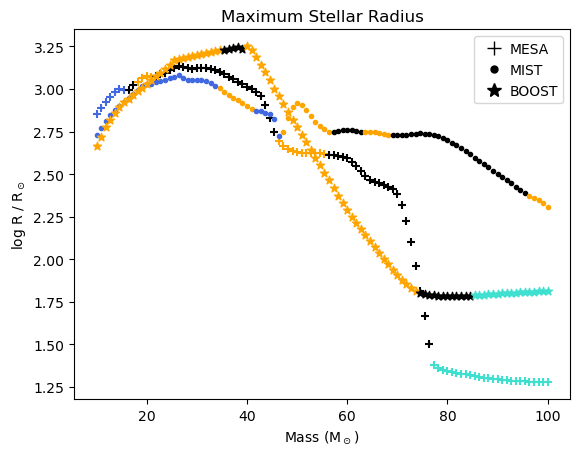

In [47]:
markerlist = ['+','.','*']

fig, ax = plt.subplots()

# Plot maximum stellar radius vs initial mass for each model grid
set0 = plot_max_rad(ax,'output_MESA',0)
set1 = plot_max_rad(ax,'output_MIST',1)
set2 = plot_max_rad(ax,'output_BOOST',2)

handles = [
    Line2D([], [], marker=marker, markersize=10, color='k', linestyle='None')
    for marker in markerlist
]
labels = ["MESA", "MIST","BOOST"]
ax.legend(handles, labels, loc = 'upper right',handletextpad = 0.1)

ax.set_xlabel(r'Mass (M$_\odot$)')
ax.set_ylabel(r'log R / R$_\odot$')
ax.set_title('Maximum Stellar Radius')


## Remnant Mass vs Initial Stellar Mass


Having explored how the maximum stellar radius varies across different stellar models,  
we can now turn to the *endpoints* of stellar evolution — the **compact remnants**.  

By plotting the final (remnant) mass as a function of the initial ZAMS mass,  
we can compare how different model grids (MESA, MIST, BOOST) predict the formation  
of neutron stars and black holes. This provides direct insight into how  
differences in stellar evolution physics influence the compact object mass spectrum.


Text(0.5, 1.0, 'Remnant Mass')

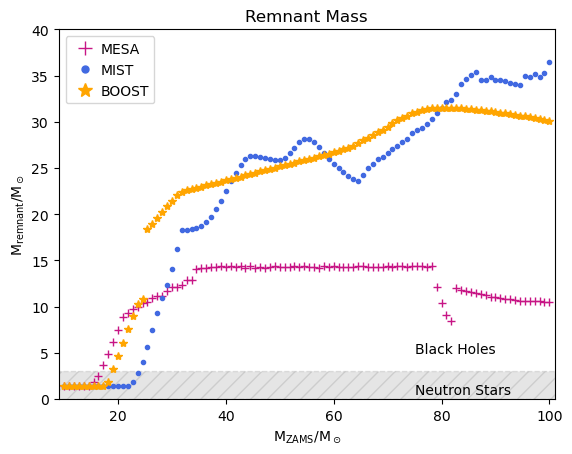

In [48]:

def plot_remnant_mass(ax, name, i):
    """
    Plot initial mass vs. remnant (final) mass for a given model.

    Parameters
    ----------
    ax : matplotlib.axes.Axes
        Axes on which to draw the points.
    name : str
        Subdirectory under run_dir containing model output files (*.dat).
    i : int
        Index selecting the color/marker for this model.
    """
    base_dir = os.path.join(run_dir, name)
    file_names = glob.glob(base_dir + "/*.dat")
    file_names.sort()  

    for eachfile in file_names:
        # Read evolution track (tabular text file)
        evolve_data = pd.read_table(eachfile, sep=r"\s+")

        # Initial stellar mass (first row of the track)
        mass = evolve_data['mass'].iloc[0]

        # Final mass after evolution (last row of the track)
        end_mass = evolve_data['mass'].iloc[-1]

        # Plot a single point: (initial mass, remnant mass)
        ax.plot(mass, end_mass, markerlist[i], color=color[i])
    return


# ---------------------------------------------------------------------
# Style setup for three models
# ---------------------------------------------------------------------
color = ['mediumvioletred', 'royalblue', 'orange']
markerlist = ['+', '.', '*']

fig, ax = plt.subplots()

# Replace with your base run directory path before running
# run_dir = "/path/to/METISSE_runs"

# ---------------------------------------------------------------------
# Plot remnant masses from each model output directory
# ---------------------------------------------------------------------
plot_remnant_mass(ax, 'output_MESA', 0)
plot_remnant_mass(ax, 'output_MIST', 1)
plot_remnant_mass(ax, 'output_BOOST', 2)

handles = [
    Line2D([], [], marker=marker, markersize=10, color=color[i], linestyle='None')
    for i, marker in enumerate(markerlist)
]
labels = ["MESA", "MIST", "BOOST"]
ax.legend(handles, labels, loc='upper left', handletextpad=0.1)

ax.set_xlabel(r'M$_{\rm ZAMS}$/M$_\odot$')         # initial (ZAMS) mass
ax.set_ylabel(r'M$_{\rm remnant}$/M$_\odot$')      # final remnant mass
ax.set_ylim(ymin=0.0, ymax=40.0)
ax.set_xlim(xmin=9.0, xmax=101.0)

# Annotate physical regions for neutron stars and black holes
ax.text(75, 0.5, 'Neutron Stars')
ax.text(75, 5.0, 'Black Holes')
plt.fill_between([0, 110], 3, hatch="//", ls='--', alpha=0.1, color='k')

ax.set_title('Remnant Mass')


The remnant mass plot summarizes the end states of stars across different model grids.  
We see how the choice of stellar tracks—MESA, MIST, or BoOST—affects the predicted  
masses of neutron stars and black holes. These differences highlight the impact of  
stellar evolution prescriptions on the outcomes of single and binary stars.
